# `msa` — Method of successive averages (MSA) on the Braess network

**What.** MSA takes a predetermined `1/k` step toward the all-or-nothing point each iteration — no line search, no objective — the simplest convergent link-based UE solver, drawn from the Robbins–Monro stochastic-approximation lineage. The trade is very slow, non-adaptive convergence, which is exactly why it is the reference slow baseline.

**Why it is in the benchmark.** It is the canonical slow baseline of the convergence ladder — it converges for the convex UE program but needs no line search, so it works even where one is unavailable (`[sheffi1985urban]`; convergence `[powell1982convergence]`). See its entry in the
[model compendium](../../docs/MODELS.md) and the certificate design in
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** This notebook runs the solver on the built-in Braess scenario (5 links,
one OD pair, no download) and certifies the result; it does not benchmark solver
families against each other — for that, see `demos/demo_quickstart.py`.

Primary reference: `[sheffi1985urban]` / `[powell1982convergence]` ([docs/REFERENCES.md](../../docs/REFERENCES.md)).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports are shown only as
provenance and diffed against the certificate as an honesty check, exactly as the
harness treats them ([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `msa` is a core model: a plain `pip install -e .` suffices — no
# optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    MSAModel,
    Budget,
    Evaluator,
    RngBundle,
    Trace,
    braess_scenario,
    viz,
)

## The scenario

The built-in Braess network: 4 nodes, 5 links, a single OD pair (1 → 2) with demand
6. Scenarios are frozen and content-hashed (P2) — the hash printed below is the
identity of the benchmark instance, so a silently edited network cannot masquerade
as it.

In [2]:
scenario = braess_scenario()
net = scenario.network

print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"links         : {net.n_links}  (tail→head: "
      + ", ".join(f"{i}->{j}" for i, j in zip(net.init_node, net.term_node)) + ")")
print(f"total demand  : {scenario.demand.total}")

scenario      : braess
content hash  : cf00f411cdccec88…
links         : 5  (tail→head: 1->3, 1->4, 3->4, 3->2, 4->2)
total demand  : 6.0


## Solve

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)`, records checkpoints, and respects the budget.
Budgets are hardware-free (iterations / shortest-path calls; wall-clock is recorded
but never the ranking axis, P7). Whatever the model writes into `self_report` is
provenance, not a score.

In [3]:
model = MSAModel()
bundle = model.solve(scenario, Budget(iterations=200), RngBundle(0), Trace())

final = bundle.final
print(f"model            : {model.name}")
print(f"budget spent     : {final.coords.iterations} iterations, "
      f"{final.coords.sp_calls} shortest-path calls")
print(f"checkpoints      : {len(bundle.trace.checkpoints)}")
print(f"emitted flows    : {np.round(final.link_flows, 6)}")
print(f"self-reported gap: {final.self_report['relative_gap']:.3e}  (provenance only)")

model            : msa
budget spent     : 200 iterations, 201 shortest-path calls
checkpoints      : 200
emitted flows    : [4.01005  1.98995  1.98995  2.020101 3.979899]
self-reported gap: 1.577e-03  (provenance only)


## Certify (P1)

The harness, never the model, computes every scored metric: the relative gap is a
property of `(link_flows, scenario)`, recomputed here by the same `Evaluator` that
scores every model in the benchmark. We also recompute the analytic Braess anchor
in-cell rather than quoting it: at UE the flows are (4, 2, 2, 2, 4) and every used
route costs 92 (pinned in [`tests/test_braess.py`](https://github.com/UMN-Choi-Lab/TABenchmark/blob/main/tests/test_braess.py)).


In [4]:
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)

certified_gap = metrics["relative_gap"]
print(f"certified relative gap : {certified_gap:.3e}")
print(f"feasible               : {metrics['feasible']:.0f}")
print(f"Beckmann objective     : {metrics['beckmann_objective']:.6f}")

# MSA converges but slowly: after 200 predetermined 1/k steps the gap is small yet
# orders above a line-search solver — honest, not machine precision.
assert metrics["feasible"] == 1.0
assert abs(certified_gap) < 1e-2

# Honesty diff (P1): this white box's self-report must match the certificate.
assert np.isclose(final.self_report["relative_gap"], certified_gap, rtol=1e-9, atol=1e-12)

# Analytic anchor, recomputed in-cell.
ref_flows = np.array([4.0, 2.0, 2.0, 2.0, 4.0])
assert evaluator.evaluate(ref_flows)["relative_gap"] < 1e-6
assert np.allclose(final.link_flows, ref_flows, atol=5e-2)
route_time = metrics["tstt"] / scenario.demand.total
print(f"route time (TSTT/D)    : {route_time:.6f}  (analytic UE: 92)")
assert abs(route_time - 92.0) < 0.1

# Certify EVERY checkpoint the same way — the trace feeds the visual below.
trace_iters = [c.coords.iterations for c in bundle.trace.checkpoints]
trace_gaps = [evaluator.evaluate(c.link_flows)["relative_gap"] for c in bundle.trace.checkpoints]
print(f"checkpoints certified  : {len(trace_gaps)} "
      f"(first gap {trace_gaps[0]:.3e}, last {trace_gaps[-1]:.3e})")

certified relative gap : 1.577e-03
feasible               : 1
Beckmann objective     : 386.002836
route time (TSTT/D)    : 91.933942  (analytic UE: 92)
checkpoints certified  : 200 (first gap 1.912e-01, last 1.577e-03)


## Visualize

Both figures come from `tabench.viz`, the house visualizer — one visual style across
every tutorial, every plotted number certified above. Left/top: the certified
equilibrium link flows on the Braess diamond. Right/bottom: the emitted flows against
the analytic UE recomputed in the previous cell — points on the `y = x` guide mean
the solver reproduced the certified equilibrium link-for-link.

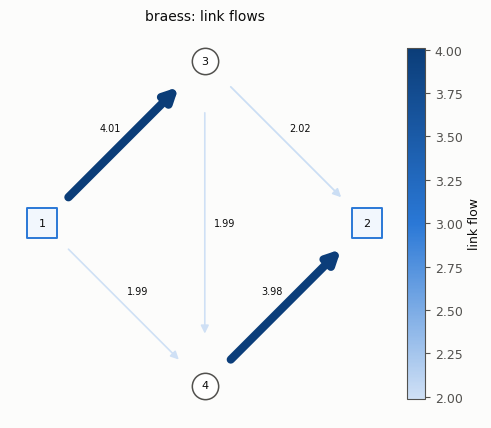

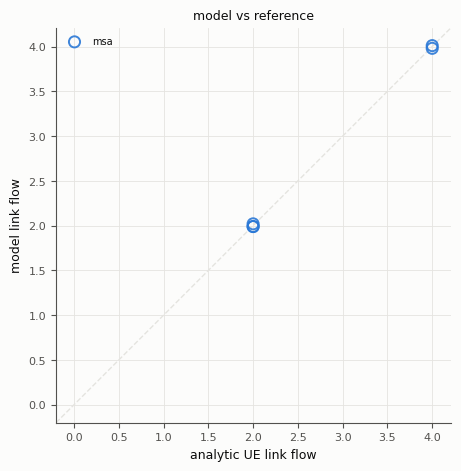

In [5]:
# Certified equilibrium flows on the network (house style via tabench.viz).
display(viz.plot_network_flows(net, final.link_flows))

# Emitted flows vs the analytic UE recomputed above (off-diagonal == disagreement).
display(viz.plot_flow_scatter(("analytic UE", ref_flows), {"msa": final.link_flows}))

## Takeaways & pointers

- **Certified, not self-reported.** The gap above came from `Evaluator`, recomputed
  from the emitted flows here; the self-report was only diffed against it.
- **Slow on purpose.** 200 predetermined `1/k` steps and the gap is still orders above `fw`/`cfw`/`bfw` — MSA trades speed for needing no objective (run it, don't quote it).
- **Where next.** the line-search solvers that leave MSA behind: [`fw`](03-fw.ipynb) · [`cfw`](04-cfw.ipynb) · [`bfw`](05-bfw.ipynb); the honest baseline: [`aon`](01-aon.ipynb); the lineage in the
  [model compendium](../../docs/MODELS.md); the full matrix via `run_experiment(...)`
  as in `demos/demo_quickstart.py`.